In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 68 (delta 20), reused 29 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 2.78 MiB | 17.25 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [16]:
# local files
from src import utils
from src.synthetic_dataset import SyntheticEllipseDataset
from src.resunet import ResUNet

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [11]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar
if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train

In [5]:
import os
from pathlib import Path
import numpy as np
import torch
from skimage.io import imread
from skimage.transform import resize

IMG_SIZE = 128

class BBBC038Dataset(Dataset):
    def __init__(self):
        self.train_dir = Path("data/stage1_train")
        self.ids = os.listdir(self.train_dir)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id = self.ids[idx]
        self.mask_dir = self.train_dir / id / "masks"
        img_path = self.train_dir / id / "images" / f"{id}.png"
        image = imread(img_path)[..., :3] / 255
        masks = [imread(self.mask_dir / f) for f in os.listdir(self.mask_dir)]
        mask = np.max(masks, axis=0) / 255

        image = resize(image, (IMG_SIZE, IMG_SIZE), preserve_range=True)
        mask = resize(mask, (IMG_SIZE, IMG_SIZE), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        image = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        mask = torch.from_numpy(mask[..., None]).permute(2, 0, 1)[0].contiguous().float()

        return image, mask

In [112]:
dataset = BBBC038Dataset()
train_dataset, val_dataset, test_dataset = random_split(dataset, [0.7, 0.15, 0.15])

In [19]:
# Treinando a ResUNet no BBBC038

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.649137020111084
0/5 - loss=0.569934606552124
0/10 - loss=0.5287591218948364
0/15 - loss=0.4553065001964569
0/20 - loss=0.43953216075897217
0/25 - loss=0.44776880741119385
0/30 - loss=0.3495008945465088
1/0 - loss=0.3045474886894226
1/5 - loss=0.3428710699081421
1/10 - loss=0.2688142657279968
1/15 - loss=0.2583722770214081
1/20 - loss=0.2699941098690033
1/25 - loss=0.23350945115089417
1/30 - loss=0.2713906764984131
2/0 - loss=0.26126423478126526
2/5 - loss=0.2495650351047516
2/10 - loss=0.21377211809158325
2/15 - loss=0.224558487534523
2/20 - loss=0.16403146088123322
2/25 - loss=0.17879267036914825
2/30 - loss=0.24541595578193665
3/0 - loss=0.3327219784259796
3/5 - loss=0.1535770148038864
3/10 - loss=0.280289888381958
3/15 - loss=0.21988168358802795
3/20 - loss=0.20064552128314972
3/25 - loss=0.15262196958065033
3/30 - loss=0.1784828007221222
4/0 - loss=0.16140297055244446
4/5 - loss=0.17053309082984924
4/10 - loss=0.15417735278606415
4/15 - loss=0.15154489874839783
4/20 - 

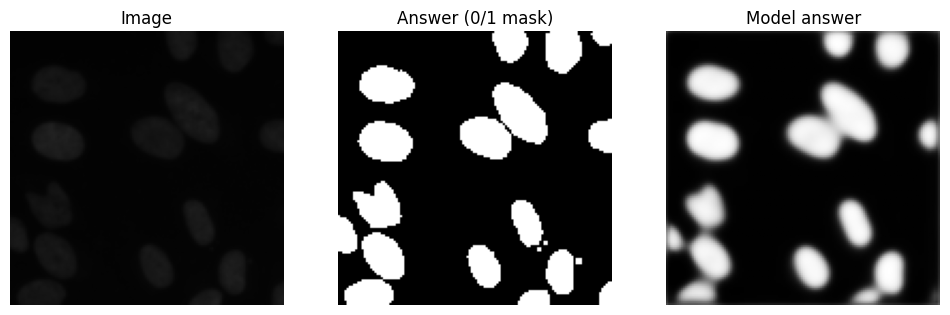

In [115]:
# Verificando a saída do modelo

model.eval()

for img, mask in DataLoader(test_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")


    plt.show()

    break

In [125]:
# computa o IoU e Dice no conjunto de validação/teste

model.eval()

iou_scores, dice_scores = [], []
final_iou_score, final_dice_score = None, None

with torch.no_grad():
    thresholds = torch.arange(0, 1, .05)

    # encontra o melhor limiar com o conjunto de validação
    iou_scores = []
    for x, y in DataLoader(val_dataset, pin_memory=True):
        y_hat = torch.sigmoid(model(x.to(device, non_blocking=True))[0, 0]).cpu()
        iou_scores.append([float(utils.iou_score(1 * (y_hat > th), y)) for th in thresholds])
        dice_scores.append([float(utils.dice_score(1 * (y_hat > th), y)) for th in thresholds])

    iou_scores = torch.tensor(iou_scores, dtype=torch.float32).mean(dim=0)
    dice_scores = torch.tensor(iou_scores, dtype=torch.float32).mean(dim=0)
    best_threshold = thresholds[iou_scores.argmax()]

    # computa o IoU e Dice pontuais no conjunto de teste
    iou_scores_test, dice_scores_test = [], []
    for x, y in DataLoader(test_dataset, pin_memory=True):
        y_hat = F.sigmoid(model(x.to(device, non_blocking=True))[0,0]).cpu()
        iou_scores_test.append(utils.iou_score(1 * (y_hat > best_threshold), y))
        dice_scores_test.append(utils.dice_score(1 * (y_hat > best_threshold), y))

    final_iou_score = np.mean(iou_scores_test).item()
    final_dice_score = np.mean(dice_scores_test).item()

/tmp/ipykernel_4032/3688162367.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dice_scores = torch.tensor(iou_scores, dtype=torch.float32).mean(dim=0)


ValueError: x and y must have same first dimension, but have shapes (20,) and (1,)

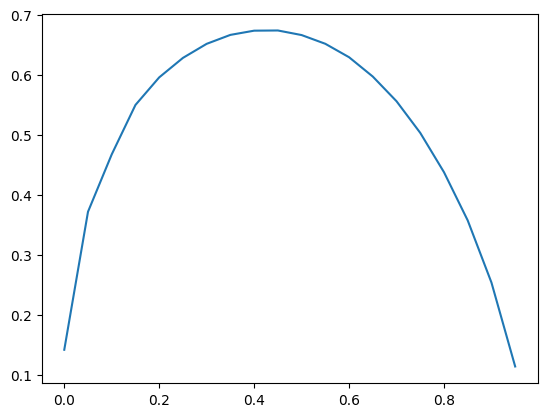

In [126]:
plt.plot(thresholds, iou_scores, label='IoU')
plt.plot(thresholds, dice_scores, label='Dice')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

print("IoU final:", final_iou_score)
print("Dice final:", final_dice_score)